# Lab : Image Classification using Convolutional Neural Networks

At the end of this laboratory, you would get familiarized with

*   Creating deep networks using Keras
*   Steps necessary in training a neural network
*   Prediction and performance analysis using neural networks

---

# **In case you use a colaboratory environment**
By default, Colab notebooks run on CPU.
You can switch your notebook to run with GPU.

In order to obtain access to the GPU, you need to choose the tab Runtime and then select “Change runtime type” as shown in the following figure:

![Changing runtime](https://miro.medium.com/max/747/1*euE7nGZ0uJQcgvkpgvkoQg.png)

When a pop-up window appears select GPU. Ensure “Hardware accelerator” is set to GPU.

# **Working with a new dataset: CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. More information about CIFAR-10 can be found [here](https://www.cs.toronto.edu/~kriz/cifar.html).

In Keras, the CIFAR-10 dataset is also preloaded in the form of four Numpy arrays. x_train and y_train contain the training set, while x_test and y_test contain the test data. The images are encoded as Numpy arrays and their corresponding labels ranging from 0 to 9.

Your task is to:

*   Visualize the images in CIFAR-10 dataset. Create a 10 x 10 plot showing 10 random samples from each class.
*   Convert the labels to one-hot encoded form.
*   Normalize the images.




In [25]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical


# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [17]:
np.savez('./cifar10_data.npz', x_train=x_train, y_train=y_train, x_test=x_test, y_test=y_test)

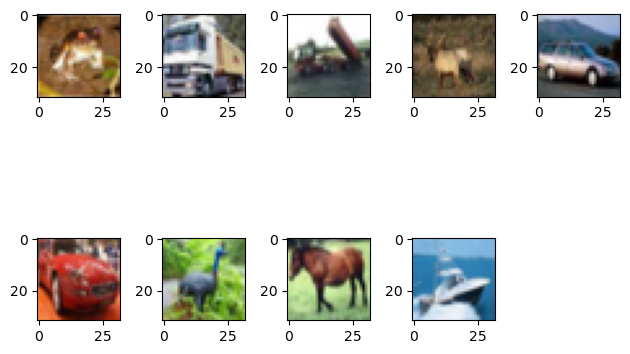

In [18]:
for i in range(9):
	plt.subplot(250 + 1 + i)
	plt.imshow(x_train[i])
plt.tight_layout()
plt.show()

In [27]:
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)
print(y_train_cat.shape)

(50000, 10)


In [20]:
x_train_normalize = x_train.astype("float32") / 255
x_test_normalize = x_test.astype("float32") / 255

## Define the following model (same as the one in tutorial)

For the convolutional front-end, start with a single convolutional layer with a small filter size (3,3) and a modest number of filters (32) followed by a max pooling layer. 

Use the input as (32,32,3). 

The filter maps can then be flattened to provide features to the classifier. 

Use a dense layer with 100 units before the classification layer (which is also a dense layer with softmax activation).

In [21]:
from keras.backend import clear_session
clear_session()

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', input_shape=(32, 32, 3)))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(100, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(10, activation='softmax'))

c:\Users\agcor\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [28]:
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train_normalize, y_train_cat, batch_size=512, epochs=50, validation_split=0.1)

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.2309 - loss: 2.1216 - val_accuracy: 0.2980 - val_loss: 2.0024
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.3121 - loss: 1.9349 - val_accuracy: 0.3394 - val_loss: 1.8951
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.3479 - loss: 1.8552 - val_accuracy: 0.3204 - val_loss: 1.8911
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.3723 - loss: 1.7937 - val_accuracy: 0.3784 - val_loss: 1.7850
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.3848 - loss: 1.7560 - val_accuracy: 0.3936 - val_loss: 1.7723
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.4009 - loss: 1.7177 - val_accuracy: 0.4064 - val_loss: 1.7117
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.4176 - loss: 1.6713 - val_accuracy: 0.3866 - val_loss: 1.7154
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.4268 - loss: 1.6463 - val_accuracy: 0.4348 - v

*   Plot the cross entropy loss curve and the accuracy curve

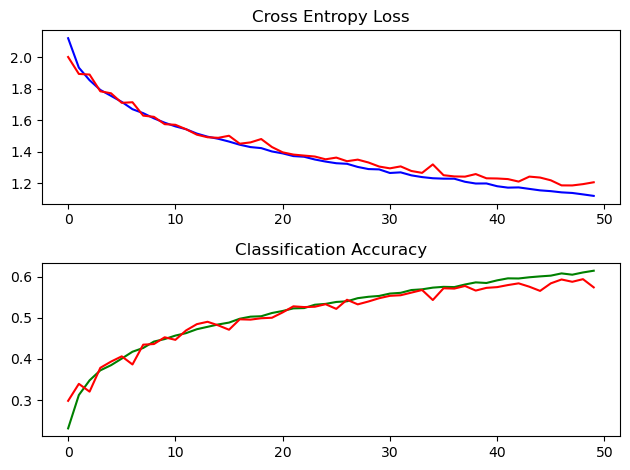

In [29]:
plt.subplot(211)
plt.title('Cross Entropy Loss')
plt.plot(history.history['loss'], color='blue', label='train')
plt.plot(history.history['val_loss'], color='red', label='val')

# plot accuracy
plt.subplot(212)
plt.title('Classification Accuracy')
plt.plot(history.history['accuracy'], color='green', label='train')
plt.plot(history.history['val_accuracy'], color='red', label='val')
plt.tight_layout()
plt.show()

## Defining Deeper Architectures: VGG Models

*   Define a deeper model architecture for CIFAR-10 dataset and train the new model for 50 epochs with a batch size of 512. We will use VGG model as the architecture.

Stack two convolutional layers with 32 filters, each of 3 x 3. 

Use a max pooling layer and next flatten the output of the previous layer and add a dense layer with 128 units before the classification layer. 

For all the layers, use ReLU activation function. 

Use same padding for the layers to ensure that the height and width of each layer output matches the input


In [30]:
from keras.backend import clear_session
clear_session()

In [31]:
model_2 = Sequential()
model_2.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', input_shape=(32, 32, 3)))
model_2.add(Conv2D(32, (3, 3), activation='relu'))
model_2.add(MaxPooling2D((2, 2)))
model_2.add(Flatten())
model_2.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
model_2.add(Dense(10, activation='softmax'))

c:\Users\agcor\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [32]:
model_2.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
history_2 = model_2.fit(x_train_normalize, y_train_cat, batch_size=512, epochs=50, validation_split=0.1)

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.2160 - loss: 2.1550 - val_accuracy: 0.2320 - val_loss: 2.1134
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.3016 - loss: 1.9790 - val_accuracy: 0.3096 - val_loss: 1.9621
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.3470 - loss: 1.8585 - val_accuracy: 0.3662 - val_loss: 1.8189
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.3745 - loss: 1.7792 - val_accuracy: 0.3850 - val_loss: 1.7740
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.3961 - loss: 1.7151 - val_accuracy: 0.3730 - val_loss: 1.7791
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.4154 - loss: 1.6685 - val_accuracy: 0.4252 - val_loss: 1.6452
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.4291 - loss: 1.6282 - val_accuracy: 0.4312 - val_loss: 1.6027
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.4469 - loss: 1.5770 - val_accuracy: 0.4430 - v

*   Compare the performance of both the models by plotting the loss and accuracy curves of both the training steps. Does the deeper model perform better? Comment on the observation.
 

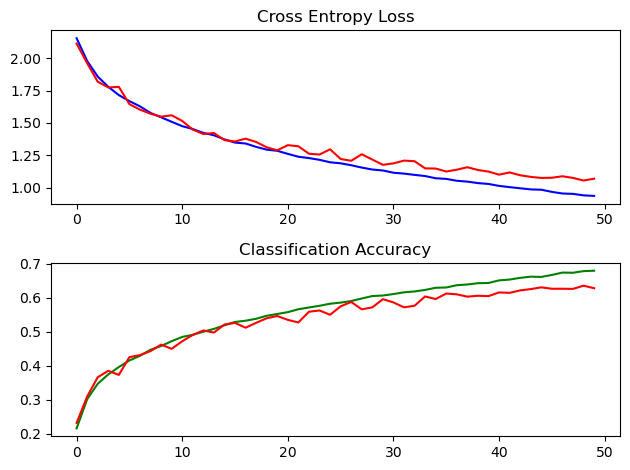

In [33]:
plt.subplot(211)
plt.title('Cross Entropy Loss')
plt.plot(history_2.history['loss'], color='blue', label='train')
plt.plot(history_2.history['val_loss'], color='red', label='val')

# plot accuracy
plt.subplot(212)
plt.title('Classification Accuracy')
plt.plot(history_2.history['accuracy'], color='green', label='train')
plt.plot(history_2.history['val_accuracy'], color='red', label='val')
plt.tight_layout()
plt.show()

**Comment on the observation**

With the second configuration, we see an improvement in the model's performance. As can be seen from the red bar indicating the validation data, it remains consistently parallel to the training data, which means that overfitting is not occurring. Furthermore, there is a slight increase in accuracy and a decrease in the number of loss errors

*   Use predict function to predict the output for the test split
*   Plot the confusion matrix for the new model and comment on the class confusions.


In [35]:
from sklearn.metrics import confusion_matrix

predictions_2 = model.predict(x_test_normalize)
confusion_matrix(np.argmax(y_test_cat, axis=1), np.argmax(predictions_2, axis=1))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[647,  52,  43,  15,  10,   7,  42,   4, 134,  46],
       [ 29, 798,   2,   5,   2,   3,  27,   6,  45,  83],
       [ 99,  23, 334,  62, 107,  59, 228,  38,  34,  16],
       [ 32,  37,  48, 376,  53,  98, 270,  30,  23,  33],
       [ 39,  13,  57,  61, 424,  22, 292,  53,  24,  15],
       [ 27,   7,  55, 196,  70, 366, 173,  60,  29,  17],
       [  6,  17,  19,  31,  30,  11, 856,   8,  11,  11],
       [ 29,  29,  31,  59,  64,  55,  96, 570,  13,  54],
       [ 92,  88,   7,  11,   5,   3,  33,   2, 725,  34],
       [ 44, 215,   4,  17,   4,   8,  52,  19,  50, 587]])

**Comment here :**

As can see the effects of possible overfitting when we saw the large number of misclassifications in the test set. The class with the most misclassifications is class 3, which is frequently confused with classes 5 and 6. The four most overrepresented classes are 1, 2, 7, and 9, which have nearly twice as many records as the rest of the classes; therefore, their weights are not balanced.

*    Print the test accuracy for the trained model.

In [37]:
test_loss, test_acc = model.evaluate(x_test_normalize, y_test_cat)
print('Test loss:', test_loss)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5683 - loss: 1.2236
Test loss: 1.2235939502716064
Test accuracy: 0.5683000087738037


## Define the complete VGG architecture.

Stack two convolutional layers with 64 filters, each of 3 x 3 followed by max pooling layer. 

Stack two more convolutional layers with 128 filters, each of 3 x 3, followed by max pooling, followed by two more convolutional layers with 256 filters, each of 3 x 3, followed by max pooling. 

Flatten the output of the previous layer and add a dense layer with 128 units before the classification layer. 

For all the layers, use ReLU activation function. 

Use same padding for the layers to ensure that the height and width of each layer output matches the input

*   Change the size of input to 64 x 64.

In [47]:
from keras.backend import clear_session
clear_session()

In [48]:
model_3 = Sequential()
model_3.add(Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_uniform', input_shape=(64, 64, 3)))
model_3.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model_3.add(MaxPooling2D((2, 2)))
model_3.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model_3.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model_3.add(MaxPooling2D((2, 2)))
model_3.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model_3.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model_3.add(MaxPooling2D((2, 2)))

model_3.add(Flatten())
model_3.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
model_3.add(Dense(10, activation='softmax'))

c:\Users\agcor\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 10 epochs with a batch size of 512.
*   Predict the output for the test split and plot the confusion matrix for the new model and comment on the class confusions.

In [49]:
print(x_train.shape)
print(y_train.shape)

(50000, 32, 32, 3)
(50000, 1)


In [50]:
model_3.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

import tensorflow as tf

X_train_resize = tf.image.resize(x_train, (64, 64)).numpy()
X_test_resize = tf.image.resize(x_test, (64, 64)).numpy()

X_train_normalized = X_train_resize.astype('float32') / 255.0
X_test_normalized = X_test_resize.astype('float32') / 255.0

num_classes = 10
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)


history_3 = model_3.fit(X_train_normalized, y_train_cat, batch_size=512, epochs=10, validation_split=0.1)

Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 298s 3s/step - accuracy: 0.1802 - loss: 2.2371 - val_accuracy: 0.1374 - val_loss: 2.3392
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 287s 3s/step - accuracy: 0.2390 - loss: 2.1189 - val_accuracy: 0.2750 - val_loss: 2.0163
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 285s 3s/step - accuracy: 0.2896 - loss: 2.0056 - val_accuracy: 0.3128 - val_loss: 1.9440
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 281s 3s/step - accuracy: 0.3322 - loss: 1.8942 - val_accuracy: 0.3478 - val_loss: 1.8075
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 285s 3s/step - accuracy: 0.3578 - loss: 1.8077 - val_accuracy: 0.3752 - val_loss: 1.7439
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 281s 3s/step - accuracy: 0.3862 - loss: 1.7400 - val_accuracy: 0.3520 - val_loss: 1.8148
Epoch 7/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 281s 3s/step - accuracy: 0.4115 - loss: 1.6705 - val_accuracy: 0.4376 - val_loss: 1.5778
Epoch 8/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 5340s 61s/step - accuracy: 0.4331 - loss: 1.6024 - val_accuracy: 0.4346 -

In [52]:
test_loss, test_acc = model_3.evaluate(X_test_normalized, y_test_cat)
print('Test loss:', test_loss)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.4685 - loss: 1.4833
Test loss: 1.4832508563995361
Test accuracy: 0.4684999883174896


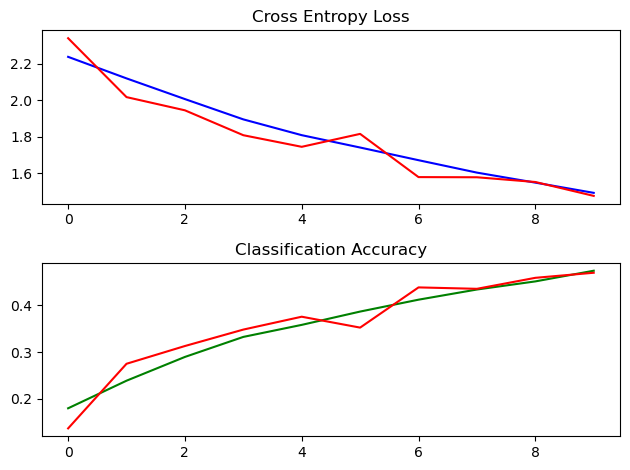

In [53]:
plt.subplot(211)
plt.title('Cross Entropy Loss')
plt.plot(history_3.history['loss'], color='blue', label='train')
plt.plot(history_3.history['val_loss'], color='red', label='val')

# plot accuracy
plt.subplot(212)
plt.title('Classification Accuracy')
plt.plot(history_3.history['accuracy'], color='green', label='train')
plt.plot(history_3.history['val_accuracy'], color='red', label='val')
plt.tight_layout()
plt.show()

In [54]:
predictions_3 = model_3.predict(X_test_normalized)
confusion_matrix(np.argmax(y_test_cat, axis=1), np.argmax(predictions_3, axis=1))

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step


array([[294,  51,  42,  42,   7,  36,  13,  30, 382, 103],
       [  2, 619,   5,  25,   1,  24,   7,  21,  78, 218],
       [ 33,  30, 300, 128,  18, 222,  94,  72,  60,  43],
       [  8,  30,  35, 380,   3, 324,  86,  44,  32,  58],
       [ 19,  24, 141, 107, 116, 179, 183, 132,  60,  39],
       [  4,  16,  42, 221,   9, 529,  43,  69,  37,  30],
       [  2,  22,  43, 180,  14, 141, 518,  22,  26,  32],
       [ 12,  23,  31,  92,   9, 146,  32, 533,  32,  90],
       [ 12,  72,   7,  20,   2,  29,  13,  13, 753,  79],
       [  3, 164,   7,  27,   2,  27,  10,  29,  88, 643]])

* As we can see from the graphs, the loss value is gradually decreasing, resulting in low accuracy for now, but the training values are stabilizing, so we could perform a greater number of iterations. In the confusion matrix, we observe that class 5 is frequently confused with the other classes, so techniques should be used to balance the weights.

# Understanding deep networks

*   What is the use of activation functions in network? Why is it needed?
*   We have used softmax activation function in the exercise. There are other activation functions available too. What is the difference between sigmoid activation and softmax activation?
*   What is the difference between categorical crossentropy and binary crossentropy loss?

**Write the answers below :**

1 - Use of activation functions:
* Without activation functions, neural networks would be nothing more than a set of linear and predictable mathematical operations, preventing them from inferring information from new data. Activation functions introduce this nonlinearity into neural networks, allowing them to infer more complex patterns from the data across layers.

2 - Key Differences between sigmoid and softmax:
* Softmax allows for multiclass classification because it assigns probabilities based on a class, and all output neurons are interconnected. In contrast, the sigmoid function maps a number to a value between 0 and 1, and the output neurons are not interconnected, so the output is unique for each one.

3 - Key Differences between categorical crossentropy and binary crossentropy loss:
* Binary cross-entropy performs binary classification, so an input can belong to multiple classes. Categorical cross-entropy, on the other hand, estimates a probability distribution, ensuring that each sample belongs to only one class.
